# Bayesian Game Outcome Modeling

This part of the project builds a Bayesian logistic regression model to estimate the probability that a home team wins a Major League Baseball game. The model uses recent team performance metrics derived from pitching, hitting, and fielding statistics, including rolling windows of starter performance, bullpen effectiveness, and offensive production. 

A Bayesian framework allows us to incorporate prior beliefs about game outcomes while estimating full posterior distributions for each model parameter. Multiple model specifications were compared using Leave-One-Out Cross Validation (LOO) to determine which combination of features provided the best predictive performance.

The final model provides probabilistic predictions for game outcomes and allows us to interpret how different aspects of team performance influence the likelihood of winning.

In [1]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from pathlib import Path
from datetime import datetime
import yaml

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    log_loss,
    confusion_matrix,
    classification_report
)

from src.preprocessing import build_feature_set
from src.models import fit_bayesian_logistic

In [2]:
game_level_features = pd.read_parquet("data/aggregated/game_level_features_22_25.parquet")
game_level_features["game_date"] = pd.to_datetime(game_level_features["game_date"], errors="coerce")
game_level_features.head(10)

,game_id,game_date,home_team,away_team,starter_pitcher_name_home,starter_pitcher_name_away,Δstarter_FIP_3G,Δstarter_WHIP_3G,Δstarter_K9_3G,Δstarter_HR9_3G,...,Δroll_3G_ISO,Δroll_7G_OBP,Δroll_7G_ISO,ΔBIP_out_rate_3G,ΔBIP_out_rate_7G,home_win,run_diff,Δwin_pct_7G,Δwin_pct_10G,ballpark
0,661042,2022-04-07,LAA,HOU,"Ohtani, Shohei","Valdez, Framber",-0.501346,-0.173269,2.362500,0.228462,...,-0.013193,-0.027160,-0.013193,-0.030054,-0.030054,0,-2,-0.111111,-0.111111,LAA
1,661577,2022-04-07,ATL,CIN,"Fried, Max","Mahle, Tyler",-0.500258,-0.156226,-1.896095,-0.385842,...,0.006274,-0.011229,0.006274,0.016629,0.016629,0,-3,0.034238,0.034238,ATL
2,662021,2022-04-07,STL,PIT,"Wainwright, Adam","Brubaker, JT",-1.496179,-0.272351,-1.838997,-1.136493,...,0.038504,0.004731,0.038504,0.028652,0.028652,1,9,0.179012,0.179012,STL
3,662571,2022-04-07,WSH,NYM,"Corbin, Patrick","Megill, Tylor",0.740873,0.193245,-2.388419,0.048493,...,0.008000,0.021413,0.008000,-0.004304,-0.004304,0,-4,-0.074074,-0.074074,WSH
4,662766,2022-04-07,KC,CLE,"Greinke, Zack","Bieber, Shane",1.678132,-0.063212,-6.238713,0.528978,...,-0.019450,0.005893,-0.019450,-0.019316,-0.019316,1,2,-0.037037,-0.037037,KC
5,663178,2022-04-07,CHC,MIL,"Hendricks, Kyle","Burnes, Corbin",3.291359,0.458473,-6.062442,1.182810,...,0.007685,-0.005448,0.007685,-0.019441,-0.019441,1,1,-0.148148,-0.148148,CHC
6,663418,2022-04-07,AZ,SD,"Bumgarner, Madison","Darvish, Yu",0.751171,0.133199,-3.039157,-0.018072,...,-0.012834,-0.011187,-0.012834,-0.013363,-0.013363,1,2,-0.166667,-0.166667,AZ
7,661041,2022-04-08,LAA,HOU,"Detmers, Reid","Odorizzi, Jake",1.796577,0.580195,0.382809,0.753655,...,-0.216749,-0.095925,-0.216749,-0.079051,-0.079051,0,-7,-1.000000,-1.000000,LAA
8,661131,2022-04-08,PHI,ATH,"Nola, Aaron","Montas, Frankie",-0.005405,-0.049099,1.079730,0.327027,...,-0.001215,-0.000515,-0.001215,-0.004885,-0.004885,1,4,-0.024691,-0.024691,PHI
9,661333,2022-04-08,NYY,BOS,"Cole, Gerrit","Eovaldi, Nathan",0.132353,-0.165441,2.382353,0.446691,...,-0.016365,-0.005154,-0.016365,0.034455,0.034455,1,1,0.000000,0.000000,NYY


## Combinations

### Base Feature Window Configurations

We define several base configurations that determine which rolling window length is used for each category of features.

| Configuration | Pitching | Batting | Fielding |
|---------------|----------|---------|----------|
| All_3G | 3G | 3G | 3G |
| Pitch7_Bat3_Field3 | 7G | 3G | 3G |
| Pitch7_Bat7_Field3 | 7G | 7G | 3G |
| Pitch3_Bat7_Field7 | 3G | 7G | 7G |
| All_7G | 7G | 7G | 7G |

These combinations allow us to explore whether different parts of the game benefit from **short-term signals (3 games)** or **slightly longer performance trends (7 games)**.

---

### Recent Winning Performance

In addition to baseball-specific metrics, we construct features representing recent team success:

- `Δwin_pct_7G`
- `Δwin_pct_10G`

These features capture the difference in recent win percentage between teams over the previous 7 or 10 games.

Because win percentage can act as a **summary measure of team momentum**, we evaluate feature sets both **with and without** these variables.

---

### Feature Set Expansion

Each base configuration is expanded into three variants:

1. **Base features only**
2. **Base features + Δwin_pct_7G**
3. **Base features + Δwin_pct_10G**

This produces:


$$5 \text{ base configurations} \times 3 \text{ variants} = 15 \text{ total feature sets}$$

This approach allows us to evaluate:

- which rolling window structure produces the most informative baseball metrics
- whether recent winning performance adds predictive value beyond those metrics

In [3]:
base_combos = [
    {"name": "All_3G", "windows": {"pitch": "3G", "bat": "3G", "field": "3G"}},
    {"name": "Pitch7_Bat3_Field3", "windows": {"pitch": "7G", "bat": "3G", "field": "3G"}},
    {"name": "Pitch7_Bat7_Field3", "windows": {"pitch": "7G", "bat": "7G", "field": "3G"}},
    {"name": "Pitch3_Bat7_Field7", "windows": {"pitch": "3G", "bat": "7G", "field": "7G"}},
    {"name": "All_7G", "windows": {"pitch": "7G", "bat": "7G", "field": "7G"}},
]

In [4]:
combos = []

for combo in base_combos:
    # No win version
    combos.append({
        "name": f"{combo['name']}_NoWin",
        "windows": combo["windows"],
        "include_win": False
    })

    # Add 7G win pct
    combos.append({
        "name": f"{combo['name']}_Win7G",
        "windows": {**combo["windows"], "win": "7G"},
        "include_win": True
    })

    # Add 10G win pct
    combos.append({
        "name": f"{combo['name']}_Win10G",
        "windows": {**combo["windows"], "win": "10G"},
        "include_win": True
    })

## Logistic Regression


### Logistic Model

For each game $i$, we have the outcome $y_i$, which is whether the home team wins or loses ($1$ for win and $0$ for loss). Furthermore we have features 

$$X_i = (x_{i1}, x_{i2}, \dots, x_{ip})$$

The bayesian logistic regression model is defined as 

$$ \text{logit}(p_i) = \alpha + \sum\limits_{j=1}^p \beta_j x_{ij} $$

where $p_i = P(y_i = 1)$ is the probability of a home win, $\alpha$ is the intercept, and $\beta_j$ is the coefficent for feature $j$. 


### Likelihood:

Given $p_i$, the outcome is:

$$y_i \sim \text{Bernoulli}(p_i) $$

Furthermore, we can parameterize $\alpha +  X_i\beta$ such that 

$$ \eta = \alpha +  X_i\beta $$

So the full likelihood is:

$$y_i \sim \text{Bernoulli}(\sigma(\eta))$$


where 

$$\sigma(\eta) = \frac{1}{1 + e^{-\eta}}$$

### Priors:

**Intercept**

The intercept prior is 

$$\alpha \sim \text{Normal}(0.12, 0.5)$$

where the prior mean of $0.12$ corresponds to a baseline home win log-odds of $0.12$, which is $53\%$. This is because, as found in [Exploratory Data Analysis](https://github.com/Sam-Gartenstein/mlb-win-prediction/blob/main/Exploratory%20Data%20Analysis.ipynb), the home team won $53\%$ of the games. 

The standard deviation of $0.5$ (this corresponds to a probability range of roughly $41\%$ to $65\%$ for a one standard deviation change around the baseline) allows for reasonable uncertainty around this baseline while still reflecting the belief that home teams tend to win slightly more often than away teams. This specification serves as a weakly informative prior, incorporating domain knowledge without strongly constraining the model.

**Coefficents**

For the predictors, the prior is 

$$\beta_j \sim  \text{Normal}(0, 1)$$

Because predictors are standardized, this prior assumes that a one-standard-deviation change in a feature typically has a modest effect on win probability while still allowing the data to estimate larger effects if supported.

### Full Data Generation Process

$$\alpha \sim \text{Normal}(0.12, 0.5)$$

$$\beta_j \sim  \text{Normal}(0, 1)$$

$$ \eta = \alpha +  X_i\beta $$

$$ p_i = \sigma(\eta_i)$$

$$\text{Bernoulli}(p_i)$$

### Modeling

Multiple Bayesian logistic regression models were fit using different combinations of rolling windows for pitching, batting, fielding statistics, and winning percentage.

In [5]:
bayes_priors = {
    "beta_mu": 0.0,
    "beta_sigma": 1.0,
    "intercept_mu": 0.12,
    "intercept_sigma": 0.5,
}

bayes_sampling = {
    "draws": 1000,
    "tune": 1000,
    "chains": 4,
    "target_accept": 0.9,
    "random_seed": 42,
}

bayes_fit_params = {
    **bayes_priors,
    **bayes_sampling,
}

In [6]:
bayes_results = {}

y = game_level_features["home_win"].astype(int)

for cfg in tqdm(combos, desc="Running Bayesian models"):
    name = cfg["name"]

    X = build_feature_set(
        game_level_features,
        windows=cfg["windows"],
        include_win=cfg.get("include_win", True),
    )

    bayes_fit = fit_bayesian_logistic(
        X,
        y,
        **bayes_fit_params,
    )

    bayes_results[name] = {
        "config": cfg,
        "X": X,
        "y": y,
        "fit": bayes_fit,
        "priors": bayes_priors.copy(),
        "sampling": bayes_sampling.copy(),
    }

Sampling 4 chains, 0 divergences ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00 / 0:00:21

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 21 seconds.


## Bayesian Model Comparison

Models are compared using **Pareto-smoothed Leave-One-Out Cross-Validation (PSIS-LOO)**. The key metric is **ELPD (Expected Log Predictive Density)**, which measures predictive performance on unseen data. Higher ELPD values indicate better predictive accuracy.


In [7]:
loo_rows = []

for name, result in tqdm(
    bayes_results.items(),
    desc="Computing LOO",
    total=len(bayes_results)
):
    loo_obj = az.loo(result["fit"]["idata"])

    loo_rows.append({
        "model": name,
        "elpd_loo": loo_obj.elpd_loo,
        "p_loo": loo_obj.p_loo,
        "se": loo_obj.se,
    })

# Create dataframe
loo_df = pd.DataFrame(loo_rows)

# Sort by best predictive performance
loo_df = loo_df.sort_values("elpd_loo", ascending=False).reset_index(drop=True)

# Compute ranking and difference from best model
best_elpd = loo_df.loc[0, "elpd_loo"]
loo_df["rank"] = loo_df.index + 1
loo_df["d_loo"] = best_elpd - loo_df["elpd_loo"]

loo_df

Computing LOO:   0%|          | 0/15 [00:00<?, ?it/s]

,model,elpd_loo,p_loo,se,rank,d_loo
0,All_7G_Win10G,-6667.048972,14.072808,13.093301,1,0.000000
1,Pitch7_Bat7_Field3_Win10G,-6667.161571,14.065670,13.104944,2,0.112598
2,Pitch7_Bat3_Field3_Win10G,-6668.431427,13.796713,12.950852,3,1.382455
3,All_7G_NoWin,-6668.813216,13.050698,12.881392,4,1.764244
4,Pitch7_Bat7_Field3_NoWin,-6669.556822,13.047760,12.837735,5,2.507850
5,All_7G_Win7G,-6669.629606,13.984172,12.871603,6,2.580634
6,Pitch7_Bat7_Field3_Win7G,-6670.028482,13.860128,12.859598,7,2.979509
7,Pitch7_Bat3_Field3_Win7G,-6673.053256,14.082233,12.626586,8,6.004284
8,Pitch7_Bat3_Field3_NoWin,-6674.971761,13.344431,12.434529,9,7.922789
9,Pitch3_Bat7_Field7_Win10G,-6678.303251,13.782266,12.131293,10,11.254279


#### Analysis 

The best-performing model by ELPD was:

**`All_7G_Win10G`**

This specification uses:

- **7-game rolling windows** for pitching, batting, and fielding statistics  
- A **10-game rolling window** for recent team win percentage

Although the second-ranked model produced a nearly identical ELPD (ΔLOO ≈ 0.11), the `All_7G_Win10G` model was selected because it achieved the highest predictive score while maintaining a consistent rolling window structure for the core performance metrics.

Overall, the model comparison suggests that **7-game performance windows capture team form more effectively than shorter 3-game windows**, while including a slightly longer **10-game win-percentage feature provides a small additional improvement in predictive performance**.

## Saving the Best Model

In [8]:
# Create shared run id
run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
print(run_id)

20260312_162444


In [9]:
run_dir = Path("artifacts/bayesian") / run_id
config_dir = run_dir / "config"
results_dir = run_dir / "results"

config_dir.mkdir(parents=True, exist_ok=False)
results_dir.mkdir(parents=True, exist_ok=False)

In [10]:
best_model_name = loo_df.loc[0, "model"]
best_cfg = next(c for c in combos if c["name"] == best_model_name)
best_fit = bayes_results[best_model_name]["fit"]

In [11]:
# Save best model
best_model_record = {
    "run_id": run_id,
    "model_name": best_model_name,
    "model_type": "bayesian_logistic",
    "features": {
        "windows": best_cfg["windows"],
        "include_win": best_cfg.get("include_win", True),
    },
    "priors": bayes_priors.copy(),
    "sampling": bayes_sampling.copy(),
    "loo_results": {
        "elpd_loo": float(loo_df.loc[0, "elpd_loo"]),
        "p_loo": float(loo_df.loc[0, "p_loo"]),
        "se": float(loo_df.loc[0, "se"]),
        "rank": int(loo_df.loc[0, "rank"]),
        "d_loo": float(loo_df.loc[0, "d_loo"]),
    },
}

with open(config_dir / "best_model_record.yaml", "w") as f:
    yaml.safe_dump(best_model_record, f, sort_keys=False)

# Save the best results
loo_df.to_csv(results_dir / "loo_results.csv", index=False)

## Diagnostics

We examine the posterior summary statistics and trace plots for the selected Bayesian logistic regression model to assess convergence and sampling stability. These diagnostics allow us to verify that the Markov chains mixed well and that the posterior estimates are reliable.

In [12]:
#best_model_name = "All_7G_Win10G"
best_fit = bayes_results[best_model_name]["fit"]

idata = best_fit["idata"]
model = best_fit["model"]
feature_names = best_fit["feature_names"]

In [13]:
posterior_summary_df = az.summary(
    best_fit["idata"],
    var_names=["intercept", "beta"],
    round_to=3,
    hdi_prob=0.95,
)

display(posterior_summary_df)

posterior_summary_df.to_csv(results_dir / "posterior_summary.csv")

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
intercept,0.120,0.021,0.079,0.161,0.000,0.000,3794.468,2751.974,1.001
beta[Δstarter_FIP_7G],-0.108,0.076,-0.256,0.040,0.002,0.001,1813.345,2590.700,1.001
beta[Δstarter_WHIP_7G],-0.046,0.033,-0.107,0.019,0.001,0.000,2915.239,3216.527,1.001
beta[Δstarter_K9_7G],0.047,0.029,-0.008,0.104,0.001,0.000,2338.459,2838.250,1.001
beta[Δstarter_HR9_7G],0.101,0.061,-0.021,0.218,0.001,0.001,1880.106,2788.620,1.001
beta[Δbullpen_FIP_7G],-0.192,0.075,-0.331,-0.041,0.002,0.001,1861.786,2433.948,1.000
beta[Δbullpen_WHIP_7G],-0.024,0.040,-0.103,0.052,0.001,0.001,2303.118,2516.647,1.001
beta[Δbullpen_K9_7G],-0.005,0.029,-0.065,0.049,0.001,0.000,2427.854,3278.061,1.000
beta[Δbullpen_HR9_7G],0.177,0.058,0.055,0.284,0.001,0.001,2080.891,2512.326,1.000
beta[Δroll_7G_OBP],-0.014,0.026,-0.065,0.038,0.000,0.000,3706.172,2914.268,1.002


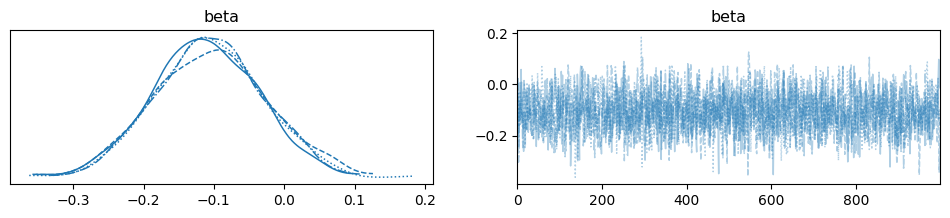

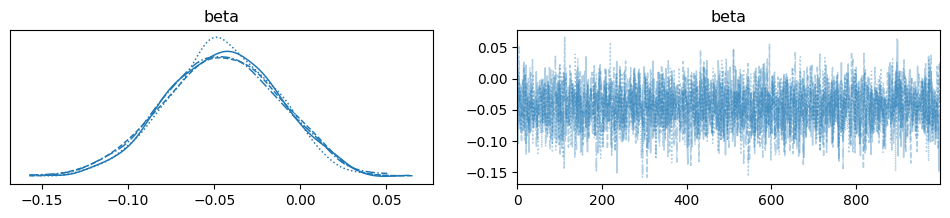

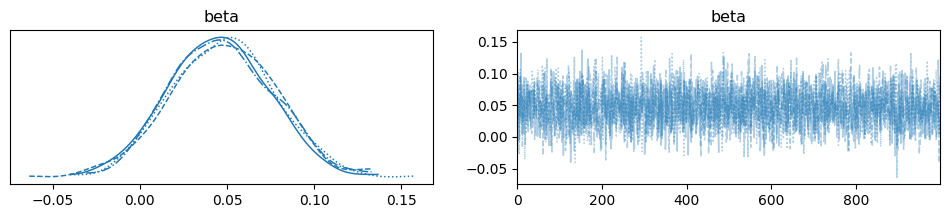

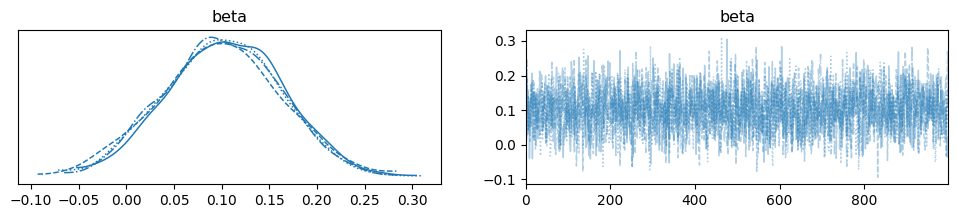

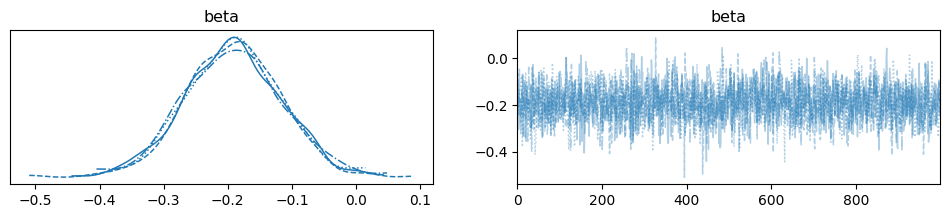

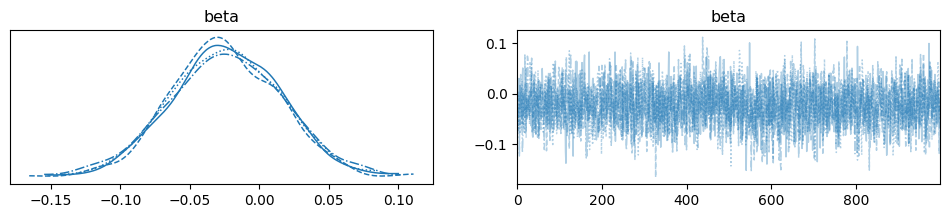

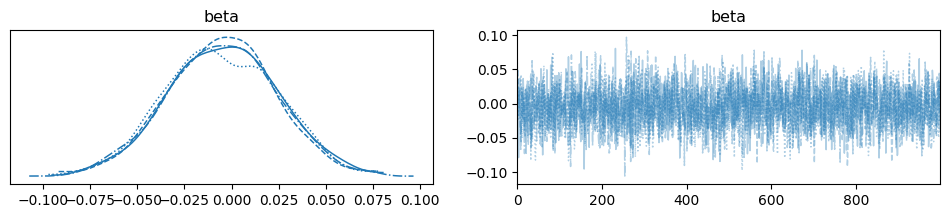

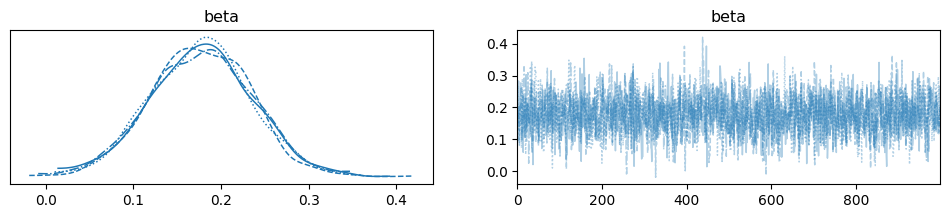

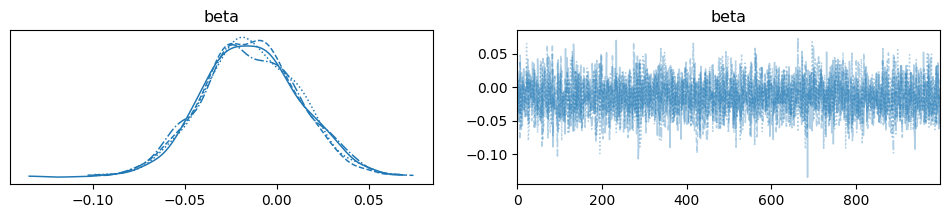

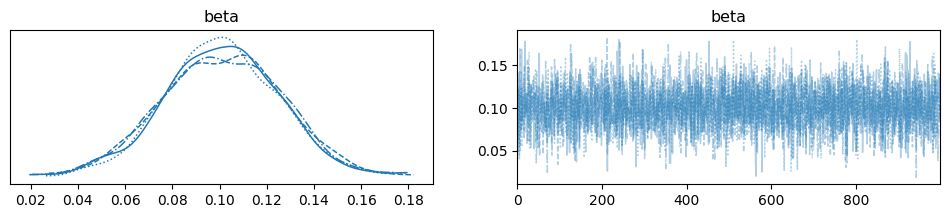

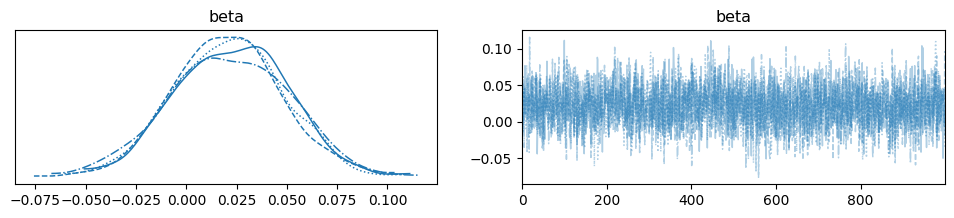

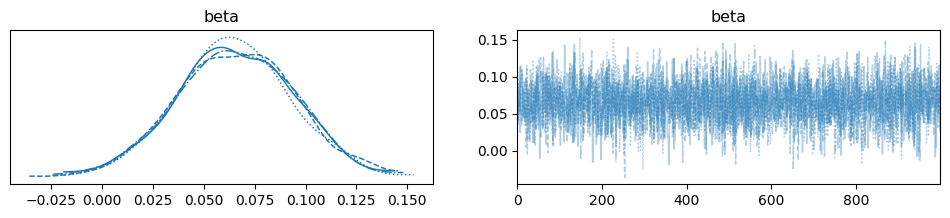

In [14]:
plots_dir = run_dir / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)

for feature in best_fit["feature_names"]:
    safe_feature = (
        str(feature)
        .replace(" ", "_")
        .replace("/", "_")
        .replace("(", "")
        .replace(")", "")
    )

    az.plot_trace(
        best_fit["idata"],
        var_names=["beta"],
        coords={"feature": [feature]},
    )

    plt.savefig(plots_dir / f"trace_beta_{safe_feature}.png", bbox_inches="tight")
    plt.show()
    plt.close()

#### Analysis

Posterior diagnostics indicate that the Bayesian logistic regression model converged successfully. All parameters have R-hat values very close to 1.0, indicating that the Markov chains mixed well and reached convergence. Additionally, the effective sample sizes (ESS) are large across all parameters, suggesting that the posterior distributions were sampled efficiently.

Trace plots further confirm good convergence behavior, showing well-mixed chains without visible drift or sticking.

The posterior estimate for the intercept is approximately 0.12, corresponding to a baseline home win probability of about 53%, which aligns closely with historical MLB home-field advantage.

Among the predictors, bullpen performance and power hitting show the strongest effects on game outcomes. In particular, bullpen FIP, bullpen home-runs per 9 rate, rolling ISO, and recent win percentage have posterior credible intervals that do not include zero, indicating stronger evidence of their influence on win probability. Other predictors show weaker or more uncertain effects but remain plausible contributors to game outcomes.

## Odds Ratios

To aid interpretation, the posterior mean coefficients were exponentiated to obtain **odds ratios**. These represent the multiplicative change in the odds of a home-team win associated with a one standard deviation increase in each predictor.

Values greater than 1 indicate an increase in win probability, while values less than 1 indicate a decrease in win probability.

In [15]:
posterior_means = (
    best_fit["idata"].posterior["beta"]
    .mean(dim=["chain", "draw"])
    .to_series()
)

beta_odds_ratio = np.exp(posterior_means).sort_values()
beta_odds_ratio = beta_odds_ratio.rename("odds_ratio")
beta_odds_ratio.index.name = "feature"

display(beta_odds_ratio)

beta_odds_ratio.to_csv(results_dir / "beta_odds_ratio.csv")

feature
Δbullpen_FIP_7G     0.825435
Δstarter_FIP_7G     0.898063
Δstarter_WHIP_7G    0.955462
Δbullpen_WHIP_7G    0.976250
Δroll_7G_OBP        0.985829
Δbullpen_K9_7G      0.994913
ΔBIP_out_rate_7G    1.021629
Δstarter_K9_7G      1.048129
Δwin_pct_10G        1.067536
Δroll_7G_ISO        1.106277
Δstarter_HR9_7G     1.106321
Δbullpen_HR9_7G     1.193636
Name: odds_ratio, dtype: float64

#### Analysis

The odds ratios suggest that starting and bullpen home runs per nine, power hitting (ISO), and recent win percentage have the strongest positive associations with game outcomes. However, the positive association for home runs per nine is somewhat counterintuitive, since allowing more home runs would generally be expected to reduce the probability of winning. 

This result likely reflects correlations between pitching metrics in the multivariate model, particularly between FIP and home runs per nine innings, as shown in the [Exploratory Data Analysis](https://github.com/Sam-Gartenstein/mlb-win-prediction/blob/main/Exploratory%20Data%20Analysis.ipynb). Because these variables capture similar aspects of pitching performance, the model coefficients represent conditional effects after accounting for the other predictors. In addition, several of the coefficients have credible intervals that include zero, indicating uncertainty in the direction of their effects. As a result, these estimates should be interpreted cautiously.

## Classification

To evaluate the final Bayesian logistic regression model as a classifier, posterior mean estimates of the intercept and coefficients were used to generate predicted win probabilities for each game. These probabilities were then converted into binary class predictions using a 0.5 threshold, and model performance was assessed using accuracy, ROC AUC, log loss, a confusion matrix, and a classification report.

In [16]:
beta = (
    best_fit["idata"]
    .posterior["beta"]
    .mean(dim=["chain", "draw"])
    .values
)

intercept = (
    best_fit["idata"]
    .posterior["intercept"]
    .mean(dim=["chain", "draw"])
    .values
)

X = best_fit["X_used"]
y = best_fit["y_used"]

logit = intercept + X @ beta
p = 1 / (1 + np.exp(-logit))

pred = (p > 0.5).astype(int)

In [17]:
# Compute metrics
accuracy = accuracy_score(y, pred)
roc_auc = roc_auc_score(y, p)
logloss = log_loss(y, p)

cm = confusion_matrix(y, pred)
class_report_dict = classification_report(y, pred, output_dict=True)
class_report_df = pd.DataFrame(class_report_dict).T

metrics_df = pd.DataFrame({
    "metric": ["accuracy", "roc_auc", "log_loss"],
    "value": [accuracy, roc_auc, logloss],
})

cm_df = pd.DataFrame(
    cm,
    index=["actual_0", "actual_1"],
    columns=["pred_0", "pred_1"],
)

In [18]:
# Display in notebook

print("Accuracy:", accuracy)
print("ROC AUC:", roc_auc)
print("Log Loss:", logloss)

print("\nConfusion Matrix")
display(cm_df)

print("\nClassification Report")
display(class_report_df)

Accuracy: 0.5513941763555922
ROC AUC: 0.569564684538777
Log Loss: 0.6845808688526452

Confusion Matrix


,pred_0,pred_1
actual_0,1548,3024
actual_1,1336,3811



Classification Report


,precision,recall,f1-score,support
0,0.536755,0.338583,0.415236,4572.000000
1,0.557571,0.740431,0.636121,5147.000000
accuracy,0.551394,0.551394,0.551394,0.551394
macro avg,0.547163,0.539507,0.525678,9719.000000
weighted avg,0.547779,0.551394,0.532212,9719.000000


In [20]:
# Save artifacts
metrics_df.to_csv(results_dir / "classification_metrics.csv", index=False)
cm_df.to_csv(results_dir / "confusion_matrix.csv")
class_report_df.to_csv(results_dir / "classification_report.csv")

#### Analysis

The model achieved an accuracy of approximately **55%**, with a **ROC AUC of 0.57**, indicating modest but meaningful predictive ability above random chance. The confusion matrix shows that the model is better at identifying home team wins than losses, with higher recall for the win class. Overall, these results suggest that while the model captures some signal from recent pitching, hitting, and team performance metrics, game outcomes remain inherently difficult to predict due to the high variability in baseball.